In [28]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt


In [29]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

In [30]:
air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

In [31]:
air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

In [32]:
dataset = pd.concat([weather, air_qual], axis=1)
dataset.drop(columns=["time"], inplace=True)

In [33]:
dataset

,dew_point_2m (°C),relative_humidity_2m (%),precipitation (mm),weather_code (wmo code),wind_speed_100m (km/h),wind_direction_10m (°),cloud_cover_high (%),cloud_cover_mid (%),cloud_cover_low (%),cloud_cover (%),surface_pressure (hPa),timestamp,pm10 (μg/m³),pm2_5 (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),carbon_monoxide (μg/m³),ozone (μg/m³)
0,1.5,88,0.0,0,22.3,233,0,0,0,0,1011.8,2016-01-01 00:00:00,12.7,5.9,22.0,3.0,188.0,34.0
1,1.0,91,0.0,0,16.8,210,14,0,0,14,1012.1,2016-01-01 01:00:00,16.5,8.6,19.0,4.1,198.0,26.0
2,0.1,92,0.0,0,15.9,189,1,0,0,1,1012.1,2016-01-01 02:00:00,21.0,12.6,20.4,4.4,202.0,27.0
3,-0.4,94,0.0,2,19.1,182,75,2,0,76,1012.8,2016-01-01 03:00:00,15.4,10.3,20.8,2.7,207.0,23.0
4,-0.5,94,0.0,3,19.7,170,100,90,0,100,1012.9,2016-01-01 04:00:00,15.7,9.1,23.0,2.2,164.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87667,-1.5,97,0.0,2,23.3,250,0,0,77,77,1017.5,2025-12-31 19:00:00,18.3,12.6,21.5,2.0,215.0,35.0
87668,-1.7,95,0.0,1,24.7,254,0,0,21,21,1016.9,2025-12-31 20:00:00,17.0,12.0,21.2,2.4,225.0,37.0
87669,-1.8,93,0.0,1,26.3,254,0,0,31,31,1015.9,2025-12-31 21:00:00,15.9,11.6,18.2,2.3,225.0,39.0
87670,-1.5,92,0.0,1,28.0,252,0,0,41,41,1014.6,2025-12-31 22:00:00,15.4,10.9,22.6,2.4,250.0,42.0


# rf base line with lag

In [34]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns

In [35]:
air_qual_no_time = dataset.drop(columns=["timestamp"]).copy()

In [36]:
df = air_qual.copy()

# Create lag features
for col in [
    "pm10 (μg/m³)",
    "pm2_5 (μg/m³)",
    "nitrogen_dioxide (μg/m³)",
    "sulphur_dioxide (μg/m³)",
    "carbon_monoxide (μg/m³)",
    "ozone (μg/m³)"
]:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag3"] = df[col].shift(3)

# Target is current PM2.5
y = df["pm2_5 (μg/m³)"]

# Keep ONLY lagged features
x = df[[c for c in df.columns if "_lag" in c]]

# Remove rows with NaNs from shifting
mask = x.notna().all(axis=1)
x = x[mask]
y = y[mask]

In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

pred = rf.predict(x_test)

In [38]:
pred = rf.predict(x_test)
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print("MAE", mae)
print("RMSE", np.sqrt(mean_squared_error(y_test, pred)))
print("R2", r2)

MAE 0.613991388160146
RMSE 0.9652411813103557
R2 0.9701230428704614


# lstm

In [39]:
dataset.set_index("timestamp", inplace=True)

In [40]:
# Separate features and target
features_df = dataset.drop(columns=["pm2_5 (μg/m³)"])
target_df = dataset[["pm2_5 (μg/m³)"]]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(features_df)
scaled_y = scaler_y.fit_transform(target_df)

lookback = 24*5
forecast_steps = 24 
# Construct inputs/outputs safely
x = []
y = []
for i in range(lookback, len(dataset) - forecast_steps + 1):
    x.append(scaled_X[i-lookback:i, :])
    y.append(scaled_y[i:i+forecast_steps, 0])

x = np.array(x)
y = np.array(y)

In [41]:
# Train/Test Split
split = int(len(x) * 0.7)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer, MultiHeadAttention, Flatten
import tensorflow.keras.backend as K


inputs = Input(shape=(x_train.shape[1], x_train.shape[2]))

lstm_1 = LSTM(256, return_sequences=True)(inputs)
drop_1 = Dropout(0.2)(lstm_1)

lstm_2 = LSTM(128, return_sequences=True)(drop_1) 
drop_2 = Dropout(0.2)(lstm_2)

lstm_3 = LSTM(64, return_sequences=True)(drop_2) 
drop_3 = Dropout(0.2)(lstm_3)

lstm_4 = LSTM(32, return_sequences=True)(drop_3) 
drop_4 = Dropout(0.2)(lstm_4)

mha = MultiHeadAttention(num_heads=4, key_dim=32)
attention_out = mha(drop_4, drop_4, drop_4)
flat = Flatten()(attention_out)

dense_1 = Dense(400, activation="relu")(flat)
drop_5 = Dropout(0.2)(dense_1)
dense_2 = Dense(200, activation="relu")(drop_5)
drop_6 = Dropout(0.2)(dense_2)
dense_3 = Dense(50, activation="relu")(drop_6)
outputs = Dense(forecast_steps)(dense_3)


model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()

NameError: name 'dense_6' is not defined

In [47]:
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=60, batch_size=32)

Epoch 1/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - loss: 0.0056 - val_loss: 0.0029
Epoch 2/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - loss: 0.0037 - val_loss: 0.0028
Epoch 3/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - loss: 0.0033 - val_loss: 0.0025
Epoch 4/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 5/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 6/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - loss: 0.0024 - val_loss: 0.0026
Epoch 7/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - loss: 0.0020 - val_loss: 0.0027
Epoch 8/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - loss: 0.0016 - val_loss: 0.0029
Epoch 9/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - loss: 0.0013 - val_loss: 0.0032
Epoch 10/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 11/60
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - loss: 9.2307e-04 - val_loss: 0.0032
Epoc

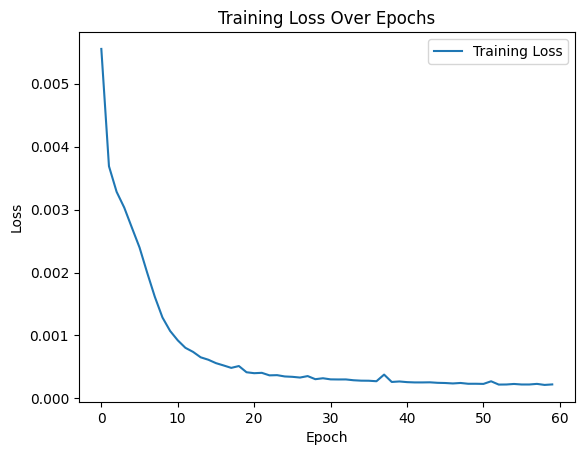

In [48]:
plt.plot(hist.history["loss"], label="Training Loss")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [49]:
pred = model.predict(x_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

821/821 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step
MAE: 0.04181452027532745
RMSE: 0.06069031706552161
R²: 0.2832817194194683


In [50]:
import plotly.graph_objects as go


y_test_pred_rescaled = scaler_y.inverse_transform(pred)
y_test_true_rescaled = scaler_y.inverse_transform(y_test)

test_start_idx = split + lookback
pm25_raw = air_qual["pm2_5 (μg/m³)"].values

# Timeline Arrays for X-axis positioning
history_x = list(range(lookback))
forecast_x = list(range(lookback, lookback + forecast_steps))

fig = go.Figure()

sample_idx = 0
global_start = test_start_idx + sample_idx

fig.add_trace(go.Scatter(
    x=history_x, 
    y=pm25_raw[global_start - lookback : global_start],
    mode='lines+markers', name='Historical PM2.5', line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_true_rescaled[sample_idx],
    mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_pred_rescaled[sample_idx],
    mode='lines+markers', name='Predicted Forecast', line=dict(color='red')
))

# 2. Build the dropdown menus for the first 50 test samples
num_samples_to_show = min(50, len(x_test))
buttons = []

for idx in range(num_samples_to_show):
    visibility = [False] * (num_samples_to_show * 3)
    visibility[idx * 3] = True
    visibility[idx * 3 + 1] = True
    visibility[idx * 3 + 2] = True
    
    button = dict(
        label=f"Sample {idx}",
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"PM2.5 Timeline: 24h History + 5-Step Forecast (Sample {idx})"}
        ]
    )
    buttons.append(button)

# 3. Generate all remaining hidden traces for the selector upfront
for idx in range(1, num_samples_to_show):
    g_start = test_start_idx + idx
    fig.add_trace(go.Scatter(
        x=history_x, y=pm25_raw[g_start - lookback : g_start],
        mode='lines+markers', name='Historical PM2.5', line=dict(color='blue'), visible=False
    ))
    # Actual
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_true_rescaled[idx],
        mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash'), visible=False
    ))
    # Predicted
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_pred_rescaled[idx],
        mode='lines+markers', name='Predicted Forecast', line=dict(color='red'), visible=False
    ))

# 4. Final Layout Customization
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, direction="down", pad={"r": 10, "t": 10}, showactive=True, x=0.02, xanchor="left", y=1.15, yanchor="top")],
    title="PM2.5 Timeline: 24h History + 5-Step Forecast (Sample 0)",
    xaxis_title="Timeline (Hours)",
    yaxis_title="PM2.5 Concentration (μg/m³)",
    height=600,
    showlegend=True
)

fig.add_vline(x=23.5, line_width=2, line_dash="dash", line_color="gray")

fig.show()

# trasnformer

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, LayerNormalization, Conv1D, GlobalAveragePooling1D
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. Data Preprocessing (Preserved)
# ==========================================
features_df = dataset.drop(columns=["pm2_5 (μg/m³)"])
target_df = dataset[["pm2_5 (μg/m³)"]]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(features_df)
scaled_y = scaler_y.fit_transform(target_df)

lookback = 24 * 5
forecast_steps = 24 

x = []
y = []
for i in range(lookback, len(dataset) - forecast_steps + 1):
    x.append(scaled_X[i-lookback:i, :])
    y.append(scaled_y[i:i+forecast_steps, 0])

x = np.array(x)
y = np.array(y)

split = int(len(x) * 0.7)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:

# ==========================================
# 2. Transformer Components
# ==========================================
class PositionalEncoding(tf.keras.layers.Layer):
    """Adds trainable embedding weights representing position along the sequence."""
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = self.add_weight(
            shape=(sequence_length, d_model),
            initializer="glorot_uniform",
            trainable=True,
            name="pos_embedding"
        )

    def call(self, inputs):
        return inputs + self.pos_emb

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    """Pre-LayerNormalization (Pre-LN) Transformer Encoder block."""
    # Attention Block
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Block (Using 1D Convolutions with kernel size 1)
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = Dropout(dropout)(x)
    
    return x + res


# ==========================================
# 3. Model Definition & Compilation
# ==========================================
seq_len = x_train.shape[1]
num_features = x_train.shape[2]
d_model = 64  # Internal hidden dimension for the Transformer

inputs = Input(shape=(seq_len, num_features))

# Step 1: Project inputs to the model dimension
x = Dense(d_model)(inputs)

# Step 2: Add temporal awareness via Positional Encodings
x = PositionalEncoding(seq_len, d_model)(x)

# Step 3: Stack Encoder Blocks
num_transformer_blocks = 2
for _ in range(num_transformer_blocks):
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)

# Step 4: Pooling instead of Flatten to prevent dense layer parameter explosion
x = GlobalAveragePooling1D()(x)

# Step 5: Dense Forecasting Head
x = Dense(200, activation="relu")(x)
x = Dropout(0.2)(x)
x = Dense(50, activation="relu")(x)
outputs = Dense(forecast_steps)(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()


In [ ]:
# ==========================================
# 4. Training & Evaluation
# ==========================================
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=60, batch_size=32)

plt.plot(hist.history["loss"], label="Training Loss")
plt.plot(hist.history["val_loss"], label="Validation Loss")
plt.title("Transformer Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
pred = model.predict(x_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

In [ ]:
# ==========================================
# 5. Interactive Visualization
# ==========================================
y_test_pred_rescaled = scaler_y.inverse_transform(pred)
y_test_true_rescaled = scaler_y.inverse_transform(y_test)

test_start_idx = split + lookback
pm25_raw = air_qual["pm2_5 (μg/m³)"].values

history_x = list(range(lookback))
forecast_x = list(range(lookback, lookback + forecast_steps))

fig = go.Figure()

sample_idx = 0
global_start = test_start_idx + sample_idx

fig.add_trace(go.Scatter(
    x=history_x, 
    y=pm25_raw[global_start - lookback : global_start],
    mode='lines+markers', name='Historical PM2.5', line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_true_rescaled[sample_idx],
    mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_pred_rescaled[sample_idx],
    mode='lines+markers', name='Predicted Forecast', line=dict(color='red')
))

num_samples_to_show = min(50, len(x_test))
buttons = []

for idx in range(num_samples_to_show):
    visibility = [False] * (num_samples_to_show * 3)
    visibility[idx * 3] = True
    visibility[idx * 3 + 1] = True
    visibility[idx * 3 + 2] = True
    
    button = dict(
        label=f"Sample {idx}",
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"PM2.5 Timeline: {lookback}h History + {forecast_steps}h Forecast (Sample {idx})"}
        ]
    )
    buttons.append(button)

for idx in range(1, num_samples_to_show):
    g_start = test_start_idx + idx
    fig.add_trace(go.Scatter(
        x=history_x, y=pm25_raw[g_start - lookback : g_start],
        mode='lines+markers', name='Historical PM2.5', line=dict(color='blue'), visible=False
    ))
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_true_rescaled[idx],
        mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash'), visible=False
    ))
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_pred_rescaled[idx],
        mode='lines+markers', name='Predicted Forecast', line=dict(color='red'), visible=False
    ))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, direction="down", pad={"r": 10, "t": 10}, showactive=True, x=0.02, xanchor="left", y=1.15, yanchor="top")],
    title=f"PM2.5 Timeline: {lookback}h History + {forecast_steps}h Forecast (Sample 0)",
    xaxis_title="Timeline (Hours)",
    yaxis_title="PM2.5 Concentration (μg/m³)",
    height=600,
    showlegend=True
)

# Places the vertical split line cleanly right at the end of history
fig.add_vline(x=lookback - 0.5, line_width=2, line_dash="dash", line_color="gray")

fig.show()